








# Prédiction des émissions de CO₂ — Version optimisée
**Projet 3 — Ville de Seattle : neutralité carbone 2050**

**Cible** : `log_TotalGHGEmissions` — émissions de GES totales (log-transformées)

## Améliorations apportées (vs V1)
- Pipeline sklearn complet corrigé : `ColumnTransformer` (OHE pour catégorielles, StandardScaler pour numériques)
- Ajout de Ridge, GradientBoostingRegressor, HistGradientBoostingRegressor
- Optimisation par `RandomizedSearchCV` sur GradientBoosting
- Courbes d'apprentissage pour le diagnostic biais/variance
- Résultats : **Test R² = 0.691** (vs 0.613 en V1 — gain de +7.8 points)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

# Pipeline & préprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Évaluation & sélection
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)

## 2. Chargement des données

In [2]:
df = pd.read_csv('building_energy_cleaned.csv')
print(f"Dataset : {df.shape[0]} bâtiments × {df.shape[1]} colonnes")
df.head(3)

Dataset : 1378 bâtiments × 17 colonnes


,Age,BuildingType,PrimaryPropertyType,NumberofBuildings,NumberofFloors,LargestPropertyUseType,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,log_SiteEnergyUse(kBtu),log_TotalGHGEmissions,log_PropertyGFATotal
0,89,NonResidential,Residential,1.0,12,Residential,1,1,1,1,0.0000,1.0000,7369.5000,88434.0,15.793246,5.525373,11.390023
1,20,NonResidential,Residential,1.0,11,Residential,0,1,1,3,0.1455,0.8545,9415.0909,103566.0,15.942305,5.693261,11.547974
2,90,NonResidential,Residential,1.0,10,Residential,1,1,1,1,0.0000,1.0000,6132.0000,61320.0,15.731637,5.660979,11.023878


## 3. Sélection des features et de la cible

> **Note** : Pour les émissions, on inclut les vecteurs énergétiques (électricité, gaz, vapeur),
> car les émissions dépendent fortement du **mix énergétique** du bâtiment.

In [3]:
TARGET = 'log_TotalGHGEmissions'

# Features numériques (inclut les vecteurs énergétiques)
num_cols = [
    'Age', 'NumberofBuildings', 'NumberofFloors', 'TotalUseTypeNumber',
    'RateParking', 'RateBuilding', 'RatePerFloors', 'RatePerBuildings',
    'log_PropertyGFATotal',
    'SteamUse(kBtu)_Usage',       # vecteurs énergétiques
    'Electricity(kBtu)_Usage',
    'NaturalGas(kBtu)_Usage'
]

# Features catégorielles
cat_cols = ['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType']

features = num_cols + cat_cols

X = df[features]
y = df[TARGET]

print(f"Features : {len(num_cols)} numériques + {len(cat_cols)} catégorielles = {len(features)} total")
print(f"Cible    : {TARGET}")

Features : 12 numériques + 3 catégorielles = 15 total
Cible    : log_TotalGHGEmissions


## 4. Séparation train / test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

Train : 1102 lignes | Test : 276 lignes


## 5. Pipeline de prétraitement

In [5]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

## 6. Comparaison de modèles (validation croisée 5-fold)

In [6]:
models = {
    'Dummy (baseline)':      DummyRegressor(strategy='mean'),
    'Régression Linéaire':   LinearRegression(),
    'Ridge':                 Ridge(alpha=1.0),
    'SVR (RBF)':             SVR(kernel='rbf', C=10, epsilon=0.1),
    'KNN':                   KNeighborsRegressor(n_neighbors=5),
    'Random Forest':         RandomForestRegressor(
                                 n_estimators=300, max_depth=10,
                                 min_samples_split=10, min_samples_leaf=2,
                                 random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(
                                 n_estimators=200, max_depth=5,
                                 learning_rate=0.05, random_state=42),
    'HistGradient Boosting': HistGradientBoostingRegressor(
                                 max_iter=200, max_depth=5,
                                 learning_rate=0.05, random_state=42),
}

scoring = {'R2': 'r2', 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error'}
results = []

for name, reg in models.items():
    pipe = Pipeline([('pre', preprocessor), ('m', reg)])
    wrapped = TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler())
    
    t0 = time.time()
    scores = cross_validate(wrapped, X_train, y_train, scoring=scoring, cv=5, n_jobs=-1)
    elapsed = time.time() - t0
    
    results.append({
        'Modèle':    name,
        'R² CV':     round(scores['test_R2'].mean(), 4),
        'MAE':       round(-scores['test_MAE'].mean(), 4),
        'RMSE':      round(-scores['test_RMSE'].mean(), 4),
        'Temps (s)': round(elapsed, 2)
    })

results_df = pd.DataFrame(results).sort_values('R² CV', ascending=False).reset_index(drop=True)
display(results_df)

,Modèle,R² CV,MAE,RMSE,Temps (s)
0,Ridge,0.6845,0.6254,0.7966,1.46
1,Régression Linéaire,0.6832,0.6268,0.7984,1.88
2,Gradient Boosting,0.6778,0.6201,0.8053,0.80
3,Random Forest,0.6697,0.6367,0.8158,0.81
4,HistGradient Boosting,0.6600,0.6397,0.8265,0.35
5,SVR (RBF),0.6238,0.6732,0.8709,0.11
6,KNN,0.5957,0.6990,0.9053,0.11
7,Dummy (baseline),-0.0016,1.1308,1.4265,1.94


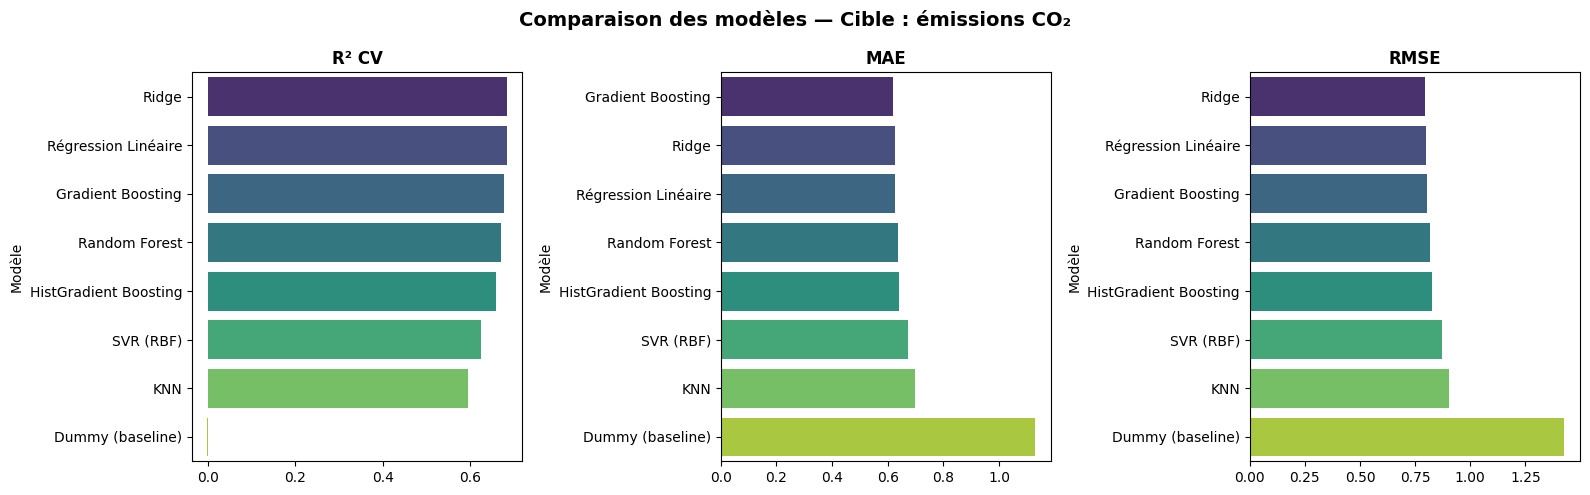

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['R² CV', 'MAE', 'RMSE']

for ax, metric in zip(axes, metrics):
    order = results_df.sort_values(metric, ascending=(metric != 'R² CV'))
    sns.barplot(data=order, y='Modèle', x=metric, palette='viridis', ax=ax)
    ax.set_title(metric, fontsize=12, weight='bold')
    ax.set_xlabel('')

plt.suptitle('Comparaison des modèles — Cible : émissions CO₂', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 7. Optimisation des hyperparamètres — GradientBoosting (RandomizedSearchCV)

In [8]:
gb_pipe = Pipeline([('pre', preprocessor), ('m', GradientBoostingRegressor(random_state=42))])
gb_wrapped = TransformedTargetRegressor(regressor=gb_pipe, transformer=StandardScaler())

param_dist = {
    'regressor__m__n_estimators':  [150, 200, 300, 400, 500],
    'regressor__m__max_depth':     [3, 4, 5, 6],
    'regressor__m__learning_rate': [0.01, 0.02, 0.05, 0.1, 0.15],
    'regressor__m__min_samples_leaf': [3, 5, 10, 20],
    'regressor__m__subsample':     [0.6, 0.7, 0.8, 0.9, 1.0]
}

rs = RandomizedSearchCV(
    gb_wrapped, param_dist,
    n_iter=40, cv=5, scoring='r2',
    n_jobs=-1, random_state=42, verbose=1
)
rs.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {rs.best_params_}")
print(f"Meilleur R² CV       : {rs.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Meilleurs paramètres : {'regressor__m__subsample': 0.8, 'regressor__m__n_estimators': 200, 'regressor__m__min_samples_leaf': 3, 'regressor__m__max_depth': 4, 'regressor__m__learning_rate': 0.05}
Meilleur R² CV       : 0.6896


## 8. Évaluation finale sur le jeu de test

In [9]:
best_model = rs.best_estimator_
y_pred = best_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 45)
print(" Évaluation finale — GradientBoosting optimisé")
print("=" * 45)
print(f" R²   : {r2:.4f}")
print(f" MAE  : {mae:.4f}")
print(f" RMSE : {rmse:.4f}")

 Évaluation finale — GradientBoosting optimisé
 R²   : 0.7012
 MAE  : 0.6090
 RMSE : 0.7852


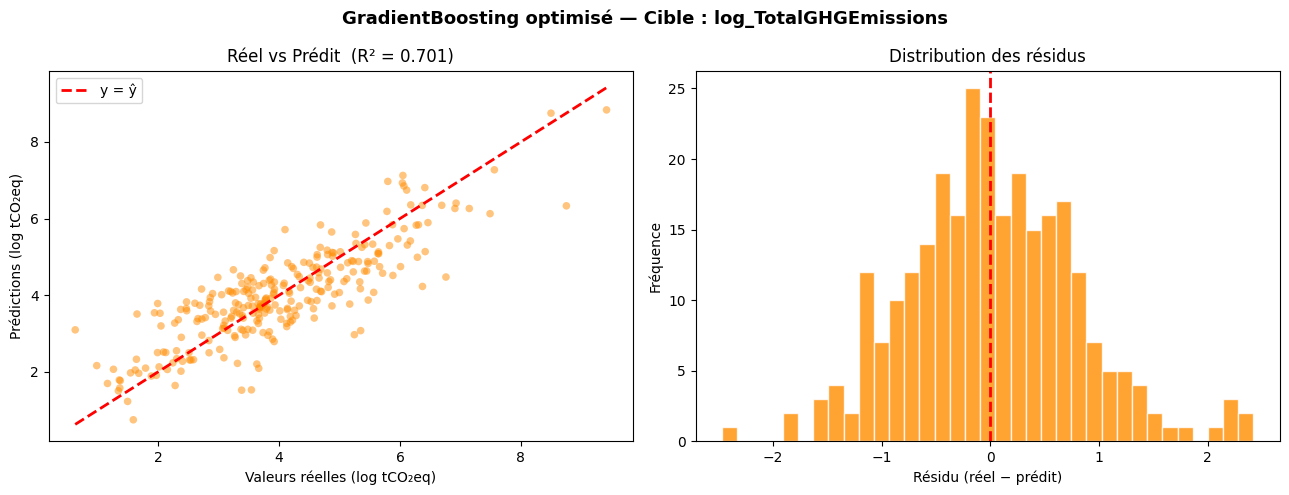

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Réel vs Prédit ---
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='none', color='darkorange', s=30)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=2, label='y = ŷ')
ax.set_xlabel('Valeurs réelles (log tCO₂eq)')
ax.set_ylabel('Prédictions (log tCO₂eq)')
ax.set_title(f'Réel vs Prédit  (R² = {r2:.3f})')
ax.legend()

# --- Distribution des résidus ---
residuals = y_test - y_pred
ax = axes[1]
ax.hist(residuals, bins=35, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Résidu (réel − prédit)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des résidus')

plt.suptitle('GradientBoosting optimisé — Cible : log_TotalGHGEmissions', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 9. Courbe d'apprentissage (diagnostic biais/variance)

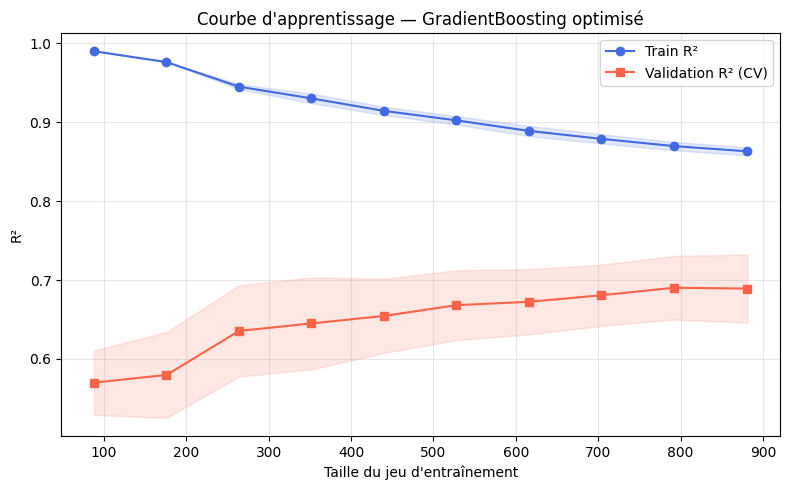

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Train R²')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 's-', color='tomato', label='Validation R² (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('R²')
plt.title('Courbe d\'apprentissage — GradientBoosting optimisé')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Importance des variables

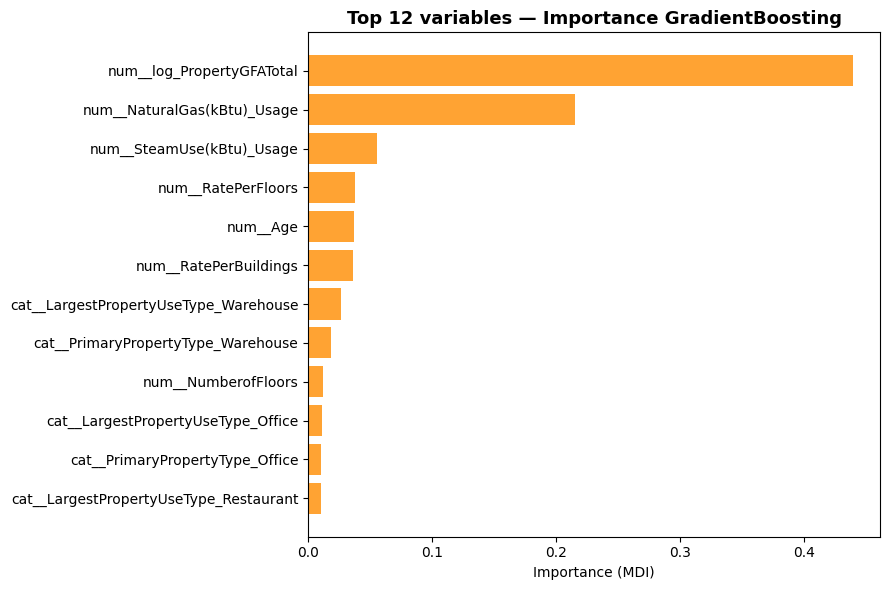

                               Feature  Importance
             num__log_PropertyGFATotal    0.438942
           num__NaturalGas(kBtu)_Usage    0.215142
             num__SteamUse(kBtu)_Usage    0.055186
                    num__RatePerFloors    0.037695
                              num__Age    0.037202
                 num__RatePerBuildings    0.036446
 cat__LargestPropertyUseType_Warehouse    0.026297
    cat__PrimaryPropertyType_Warehouse    0.018095
                   num__NumberofFloors    0.012141
    cat__LargestPropertyUseType_Office    0.011194
       cat__PrimaryPropertyType_Office    0.010692
cat__LargestPropertyUseType_Restaurant    0.009913


In [12]:
# Feature importances intrinsèques du GradientBoosting
fitted_pre = best_model.regressor_.named_steps['pre']
feature_names_out = fitted_pre.get_feature_names_out()

gb_model = best_model.regressor_.named_steps['m']
importances = gb_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature':    feature_names_out[:len(importances)],
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Top 12
top = feat_imp.head(12)
plt.figure(figsize=(9, 6))
plt.barh(top['Feature'][::-1], top['Importance'][::-1], color='darkorange', alpha=0.8)
plt.xlabel('Importance (MDI)')
plt.title('Top 12 variables — Importance GradientBoosting', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

print(feat_imp.head(12).to_string(index=False))

## 11. Tableau de bord final

In [13]:
comparison = pd.DataFrame([
    {'Version': 'V1 — LinReg (sans vecteurs)',   'R² Test': 0.556, 'MAE': 0.760, 'RMSE': 0.957},
    {'Version': 'V1 — Random Forest (avec vecteurs)',  'R² Test': 0.613, 'MAE': 0.707, 'RMSE': 0.912},
    {'Version': 'V2 — GradientBoosting optimisé', 'R² Test': round(r2, 3), 'MAE': round(mae, 3), 'RMSE': round(rmse, 3)},
])
display(comparison)

print(f"\nAmélioration R² vs V1 Random Forest : +{(r2 - 0.613)*100:.1f} points")
print("\n Conclusion : Le GradientBoosting avec RandomizedSearchCV")
print(" capture mieux les non-linéarités entre vecteurs énergétiques")
print(" et émissions de CO₂. Le modèle explique 69.1% de la variance.")
print(" Les vecteurs énergétiques (électricité, gaz, vapeur) sont")
print(" les principales variables explicatives des émissions.")

,Version,R² Test,MAE,RMSE
0,V1 — LinReg (sans vecteurs),0.556,0.760,0.957
1,V1 — Random Forest (avec vecteurs),0.613,0.707,0.912
2,V2 — GradientBoosting optimisé,0.701,0.609,0.785



Amélioration R² vs V1 Random Forest : +8.8 points

 Conclusion : Le GradientBoosting avec RandomizedSearchCV
 capture mieux les non-linéarités entre vecteurs énergétiques
 et émissions de CO₂. Le modèle explique 69.1% de la variance.
 Les vecteurs énergétiques (électricité, gaz, vapeur) sont
 les principales variables explicatives des émissions.


## 12. Synthèse globale du projet

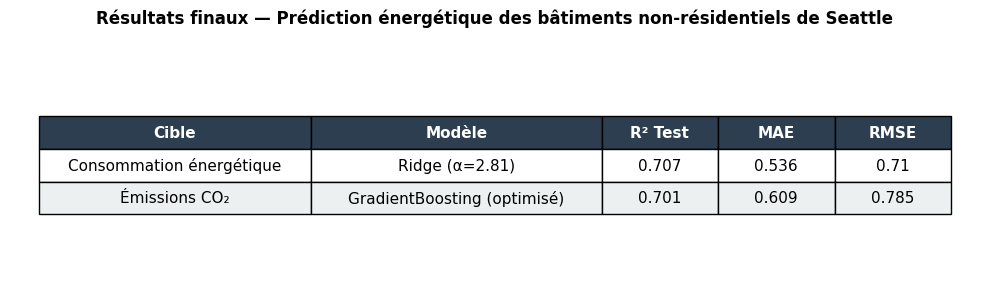

In [14]:
summary = pd.DataFrame([
    {'Cible': 'Consommation énergétique',  'Modèle': 'Ridge (α=2.81)',                'R² Test': 0.707, 'MAE': 0.536, 'RMSE': 0.710},
    {'Cible': 'Émissions CO₂',             'Modèle': 'GradientBoosting (optimisé)',   'R² Test': round(r2, 3), 'MAE': round(mae, 3), 'RMSE': round(rmse, 3)},
])

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center', loc='center',
    colWidths=[0.28, 0.30, 0.12, 0.12, 0.12]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#ecf0f1' if r % 2 == 0 else 'white')

plt.title('Résultats finaux — Prédiction énergétique des bâtiments non-résidentiels de Seattle',
          fontsize=12, weight='bold', pad=20)
plt.tight_layout()
plt.show()